In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd
from scipy.stats import t
from triangular_transport.flows.methods.sampling import inf_train_gen

plt.style.use("ggplot")

In [2]:
def mean_ci95(runs, axis=0):
    n = runs.shape[axis]
    mean = np.mean(runs, axis=axis)
    std = np.std(runs, axis=axis, ddof=1)
    sem = std / np.sqrt(n)
    tcrit = t.ppf(0.975, df=n-1)

    low = mean - tcrit * sem
    high = mean + tcrit * sem

    return mean, low, high

In [3]:
mcmc_4 = np.load("mcmc_results_4/avg_wd_mcmc.npy")
mcmc_0 = np.load("mcmc_results_0/avg_wd_mcmc.npy")
mcmc_1 = np.load("mcmc_results_1/avg_wd_mcmc.npy")
sample_no_list = np.load("sample_no_list.npy").tolist()

In [4]:
no_trials = 10
ode_array_4 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_4[i, :] = np.load(f"converge_results_4/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_4, l_ode_4, h_ode_4 = mean_ci95(ode_array_4)

ode_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_0[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_0, l_ode_0, h_ode_0 = mean_ci95(ode_array_0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_banana/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_1, l_ode_1, h_ode_1 = mean_ci95(ode_array_1)


In [5]:
sde_array_4 = np.zeros((no_trials, 23))
for i in range(no_trials):
    sde_array_4[i, :] = np.load(f"converge_results_4_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean_4, l_sde_4, h_sde_4 = mean_ci95(sde_array_4)

sde_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    sde_array_0[i, :] = np.load(f"converge_results_0_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean_0, l_sde_0, h_sde_0 = mean_ci95(sde_array_0)

sde_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    sde_array_1[i, :] = np.load(f"converge_results_1_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean_1, l_sde_1, h_sde_1 = mean_ci95(sde_array_1)

In [6]:
ker_array_4 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ker_array_4[i, :] = np.load(f"converge_results_4_kernel/run_{i:02d}/nn_conv_wd_{i}.npy")
ker_mean_4, l_ker_4, h_ker_4 = mean_ci95(ker_array_4)

ker_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ker_array_0[i, :] = np.load(f"converge_results_0_kernel/run_{i:02d}/nn_conv_wd_{i}.npy")
ker_mean_0, l_ker_0, h_ker_0 = mean_ci95(ker_array_0)

ker_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ker_array_1[i, :] = np.load(f"converge_results_1_kernel/run_{i:02d}/nn_conv_wd_{i}.npy")
ker_mean_1, l_ker_1, h_ker_1 = mean_ci95(ker_array_1)

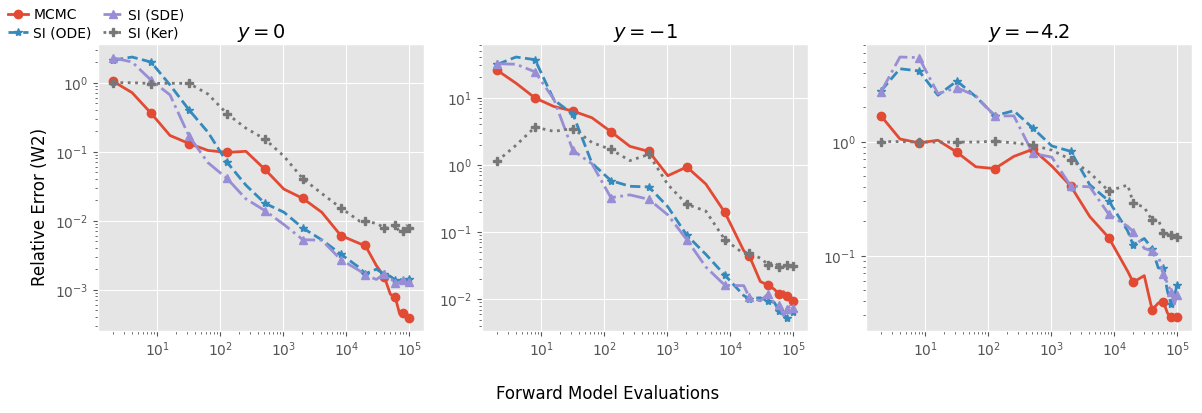

In [7]:
eps = 1e-300

fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].plot(sample_no_list, mcmc_0, marker="o", label="MCMC", markevery=2, linewidth=2, markersize=6,)
imode0, = ax[0].plot(sample_no_list, ode_mean_0, marker="*", linestyle="dashed", label="SI (ODE)", linewidth=2, markersize=6, markevery=2)
# ax[0].fill_between(sample_no_list, np.clip(l_ode_0, eps, None), np.clip(h_ode_0, eps, None), alpha=0.12, color=imode0.get_color())
imsde0, = ax[0].plot(sample_no_list, sde_mean_0, marker="^", linestyle="dashdot", label="SI (SDE)", markevery=2, linewidth=2, markersize=6,)
# ax[0].fill_between(sample_no_list, np.clip(l_sde_0, eps, None), np.clip(h_sde_0, eps, None), alpha=0.12, color=imsde0.get_color())
imker0, = ax[0].plot(sample_no_list, ker_mean_0, marker="P", linestyle="dotted", label="SI (Ker)", markevery=2, linewidth=2, markersize=6,)
# ax[0].fill_between(sample_no_list, np.clip(l_ker_0, eps, None), np.clip(h_ker_0, eps, None), alpha=0.12, color=imker0.get_color())
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y = 0$", fontsize=14, pad=4)

ax[1].plot(sample_no_list, mcmc_1, marker="o", markevery=2, linewidth=2, markersize=6,)
imode1, = ax[1].plot(sample_no_list, ode_mean_1, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
# ax[1].fill_between(sample_no_list, np.clip(l_ode_1, eps + 0.002, None), np.clip(h_ode_1, eps, None), alpha=0.12, color=imode1.get_color())
imsde1, = ax[1].plot(sample_no_list, sde_mean_1, marker="^", linestyle="dashdot", markevery=2, linewidth=2, markersize=6,)
# ax[1].fill_between(sample_no_list, np.clip(l_sde_1, eps, None), np.clip(h_sde_1, eps, None), alpha=0.12, color=imsde1.get_color())
imker1, = ax[1].plot(sample_no_list, ker_mean_1, marker="P", linestyle="dotted", label="SI (Ker) - WD", markevery=2, linewidth=2, markersize=6,)
# ax[1].fill_between(sample_no_list, np.clip(l_ker_1, eps, None), np.clip(h_ker_1, eps, None), alpha=0.12, color=imker1.get_color())
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y = -1$", fontsize=14, pad=4)

ax[2].plot(sample_no_list, mcmc_4, marker="o", markevery=2, linewidth=2, markersize=6,)
imode2, = ax[2].plot(sample_no_list, ode_mean_4, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
# ax[2].fill_between(sample_no_list, np.clip(l_ode_4, eps, None), np.clip(h_ode_4, eps, None), alpha=0.12, color=imode2.get_color())
imsde2, = ax[2].plot(sample_no_list, sde_mean_4, marker="^", linestyle="dashdot", markevery=2, linewidth=2, markersize=6,)
# ax[2].fill_between(sample_no_list, np.clip(l_sde_4, eps, None), np.clip(h_sde_4, eps, None), alpha=0.12, color=imsde2.get_color())
imker2, = ax[2].plot(sample_no_list, ker_mean_4, marker="P", linestyle="dotted", markevery=2, linewidth=2, markersize=6,)
# ax[2].fill_between(sample_no_list, np.clip(l_ker_4, eps, None), np.clip(h_ker_4, eps, None), alpha=0.12, color=imker2.get_color())
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y = -4.2$", fontsize=14, pad=4)

fig.supylabel("Relative Error (W2)")
fig.supxlabel("Forward Model Evaluations")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,          # or smaller if needed
    handlelength=1.4,     # length of line samples
    handletextpad=0.4,    # space between handle and text
    columnspacing=0.8,    # space between columns
    labelspacing=0.3,     # vertical space between rows
    borderaxespad=0.2,    # distance to axes
)

plt.tight_layout()
plt.savefig("images/conv_plot_banana.pdf")

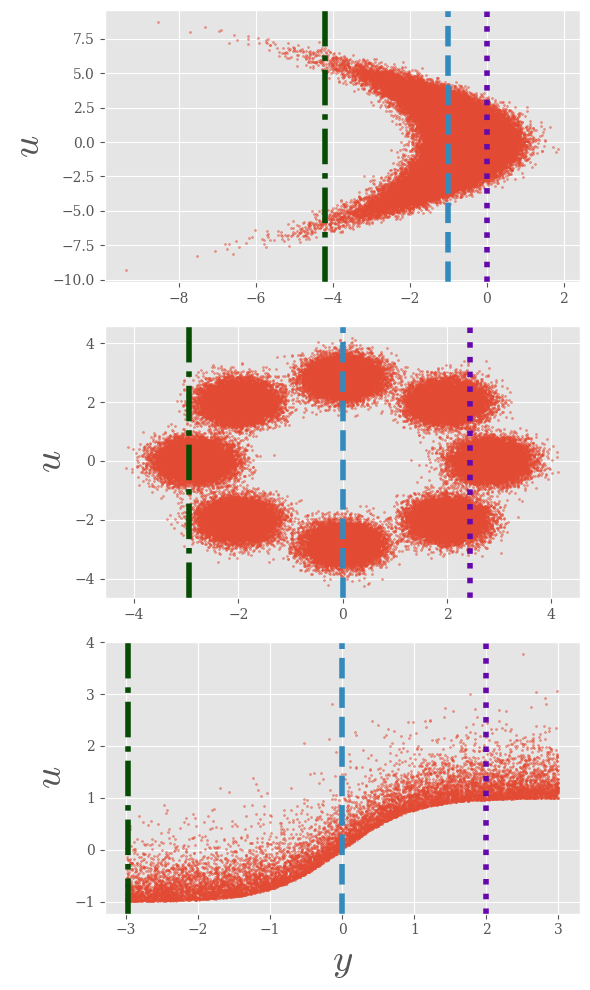

In [76]:
banana_samps = inf_train_gen(data="banana", batch_size=100000)
gauss_samps = inf_train_gen(data="8gaussians", batch_size=100000)
yst = np.random.uniform(low=-3.0, high=3.0, size=(10000, 1))
ust = np.tanh(yst) + np.random.gamma(shape=1.0, scale=0.3, size=(10000, 1))
tanh_samps = np.hstack([yst, ust])

fig, ax = plt.subplots(3, 1, figsize=(6, 10))
ax[0].scatter(banana_samps[:, 0], banana_samps[:, 1], alpha=0.5, s=2)
# ax[0].set_xlabel(r"$y$")
ax[0].set_ylabel(r"$u$", fontsize=28)
ax[0].axvline(x=-1, linestyle="--", linewidth=4, c='#348abd')
ax[0].axvline(x=-4.2, linestyle="dashdot", linewidth=4, c="#074c05")
ax[0].axvline(x=0, linestyle="dotted", linewidth=4, c="#6609ac")
ax[1].scatter(gauss_samps[:, 0], gauss_samps[:, 1], alpha=0.5, s=2)
ax[1].set_ylabel(r"$u$", fontsize=28)
ax[1].axvline(x=0, linestyle="--", linewidth=4, c='#348abd')
ax[1].axvline(x=2.45, linestyle="dotted", linewidth=4, c="#6609ac")
ax[1].axvline(x=-2.95, linestyle="dashdot", linewidth=4, c="#074c05")
ax[2].scatter(yst, ust, alpha=0.5, s=2)
ax[2].set_xlabel(r"$y$", fontsize=28)
ax[2].set_ylabel(r"$u$", fontsize=28)
ax[2].axvline(x=0, linestyle="--", linewidth=4, c='#348abd')
ax[2].axvline(x=2, linestyle="dotted", linewidth=4, c="#6609ac")
ax[2].axvline(x=-2.97, linestyle="dashdot", linewidth=4, c="#074c05")

plt.tight_layout()
plt.savefig("images/banana_8gauss_tanh.png", dpi=900, bbox_inches="tight")

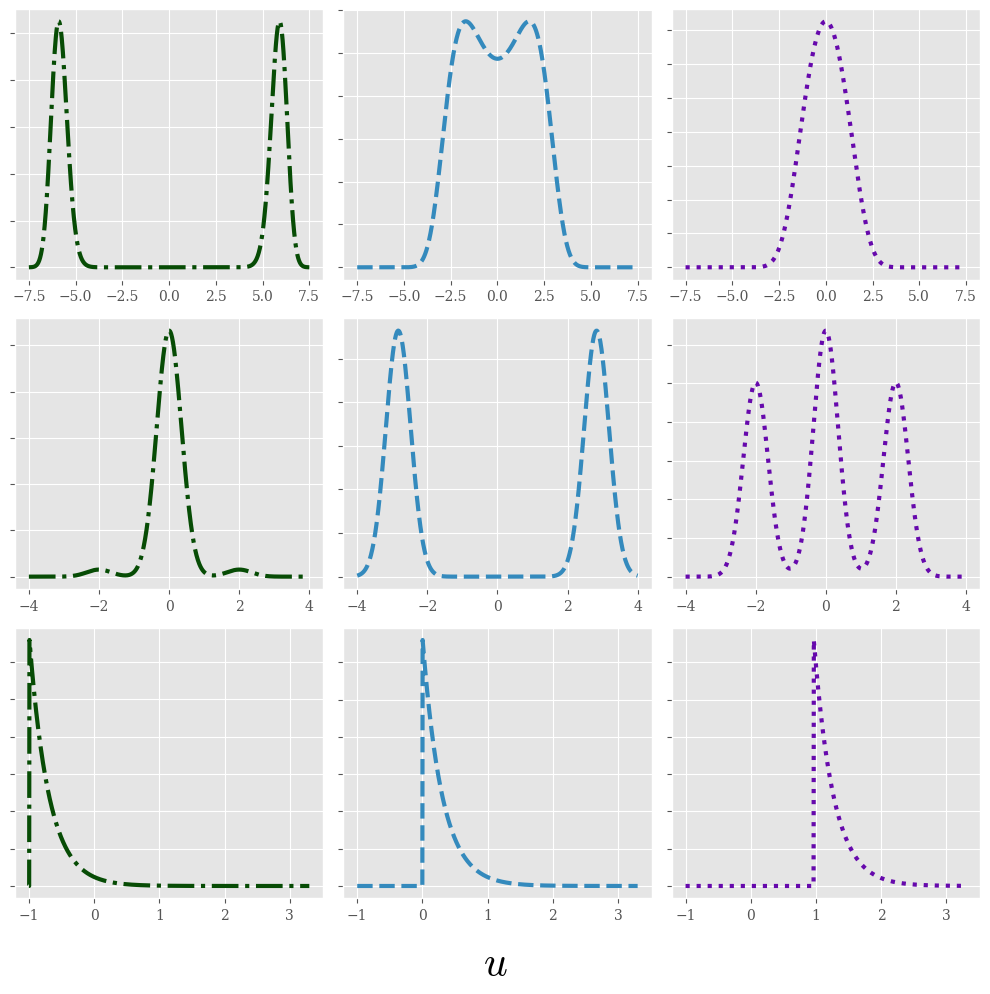

In [77]:
a = 2
b = 0.1
sigma_x = 1
def banana_density(y, u):
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return np.exp(-scale * sum_part).item()

def g8_density(y, u):
    scale = 4.0
    u = np.asarray(u)
    if u.ndim > 0:
        u = u.item()
    y = float(np.asarray(y).item())
    centers = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        ]
    centers = np.array([((scale * x) / np.sqrt(2), (scale * y) / (np.sqrt(2))) for x, y in centers], dtype="float32")
    factor = 1 / np.sqrt(np.pi)
    x = np.array([y, u])
    x = np.full((8, 2), fill_value=x)
    norm_part = np.sum((x - centers) * (x - centers), axis=1)
    exp_part = np.exp(-scale * norm_part)
    sum_part = np.sum(exp_part)
    return (factor * sum_part).item()

def tanh_density(y, u, scale=0.3):
    shift = np.tanh(y)
    if u < shift:
        return 0.0
    return (1/scale) * np.exp(-(u - shift)/scale)

cond_vals_b = [-4.2, -1.0, 0.0]
cond_vals_8g = [-2.95, 0.0, 2.45]
cond_vals_tanh = [-2.97, 0.0, 2.0]
fig, ax = plt.subplots(3, 3, figsize=(10,10))
for i in range(3):
    if i == 0:
        density = banana_density
        lo, hi = -7.5, 7.5
        cond_vals = cond_vals_b
    elif i == 1:
        density = g8_density
        lo, hi = -4, 4
        cond_vals = cond_vals_8g
    else:
        density = tanh_density
        lo, hi = -1, 3.3
        cond_vals = cond_vals_tanh
    for j in range(3):
        density_vals = [density(cond_vals[j], u) for u in np.linspace(lo, hi, 1000)]
        if j == 0:
            linestyle = "dashdot"
            c = "#074c05"
        elif j == 1:
            linestyle = "--"
            c = '#348abd'
        else:
            linestyle = "dotted"
            c = "#6609ac"
        ax[i, j].plot(np.linspace(lo, hi, 1000), density_vals, linestyle=linestyle, c=c, linewidth=3.0)
        ax[i, j].set_yticklabels([])
        ax[i, j].tick_params(labelleft=False)

fig.supxlabel(r"$u$", fontsize=30)
plt.tight_layout()
plt.savefig("images/cond_plots.png", dpi=600, bbox_inches="tight")

In [6]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math
})

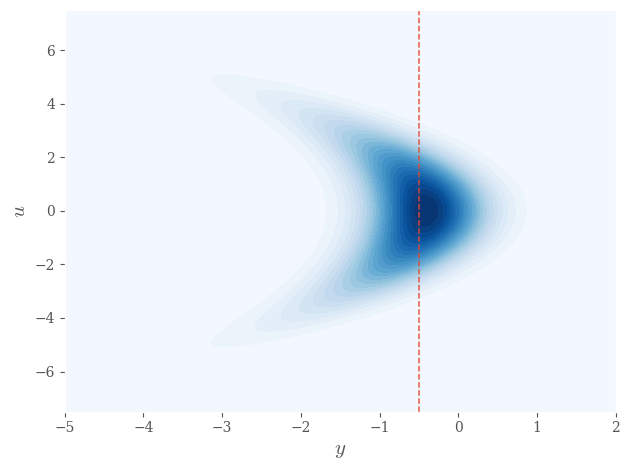

In [15]:
a = 2
b = 0.1
sigma_x = 1
XX = inf_train_gen(data="banana", batch_size=3000)
# This is the function we want to sample from.
def V(y, u):
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return np.exp(-scale * sum_part)


# Defining variables to create the contour plot
y = np.linspace(-10, 10, 1000)
u = np.linspace(-10, 10, 1000)
X, Y = np.meshgrid(y, u)
Z = V(X, Y)

# plt.figure(figsize=(8, 5))
contour = plt.contourf(
    X, Y, Z, levels=30, cmap="Blues"
) 
plt.axvline(x=-0.5, linestyle="--", linewidth=1.1, alpha=0.9)

plt.xlabel(r"$y$", size=15)
plt.ylabel(r"$u$", size=15)

plt.xlim(-5.0, 2.0)
plt.ylim(-7.5, 7.5)
plt.grid(False)
plt.tight_layout()
plt.show()

In [155]:
mcmc_samps1 = np.load("mcmc_results/mcmc_samps.npy")[7].squeeze()
mcmc_samps0 = np.load("mcmc_results_0/mcmc_samps.npy")[7].squeeze()
mcmc_samps4 = np.load("mcmc_results_4/mcmc_samps.npy")[0].squeeze()

In [3]:
@vmap
def trig_interpolant_noise(t: jnp.array, x1: jnp.array, x0: jnp.array, z: jnp.array):
    return (
        jnp.cos((jnp.pi / 2) * t) * x0
        + jnp.sin((jnp.pi / 2) * t) * x1
        + gamma_vmap(t) * z
    )


@vmap
def trig_interpolant_der_noise(
    t: jnp.array, x1: jnp.array, x0: jnp.array, z: jnp.array
):
    return (jnp.pi / 2) * (
        -jnp.sin((jnp.pi / 2) * t) * x0
        + jnp.cos((jnp.pi / 2) * t) * x1
    ) + gammadot(t) * z

def gamma(t):
    return 0.1 * jnp.sqrt(2 * t * (1 - t) + 1e-8)

@vmap
def gammadot(t):
    return 0.1 * (1 - 2 * t) / jnp.sqrt(t - t ** 2 + 1e-8)

gamma_vmap = vmap(gamma)

In [74]:
epochs = 7000
sample_no = 100000
rng2 = np.random.RandomState(0)
x1_data = inf_train_gen(data="banana", rng=rng2, batch_size=100000)
key = random.PRNGKey(0 + 1 + 0)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = sample_no
batch_size = 2048
# batch_size = hyperparams["batch_size"]
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
# steps = 50000
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 4
# hidden_layer_list = [1024] * 8
target_data = x1_data[:sample_no, :]
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2000,
    decay_steps=steps,
    end_value=1e-5,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adam(schedule)
)
# optimizer = optax.adam(1e-5)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 0/343000 [00:00<?, ?it/s]

  0%|          | 71/343000 [00:01<1:11:55, 79.47it/s] 

step = 0, train_loss = -0.00010048877447843552


  3%|▎         | 10141/343000 [00:13<06:50, 810.64it/s]

...

step = 330000, train_loss = -2.5715744495391846


 99%|█████████▉| 340124/343000 [07:07<00:03, 809.04it/s]

step = 340000, train_loss = -3.0717358589172363


100%|██████████| 343000/343000 [07:11<00:00, 794.86it/s]

step = 342999, train_loss = -2.9946558475494385


In [20]:
with open("cond_values_fm.pkl", "rb") as file:
    grid_dens = pickle.load(file)
grids = []
density_values = []
cond_samps = []
for cond in grid_dens:
    grids.append(cond[1])
    density_values.append(cond[2])
    cond_samps.append(cond[0][:, 1:])
cond_samps = np.hstack(cond_samps)

In [163]:
cond_vals = [0.0, -1.0, -4.2]
cond_samples = trainer.conditional_sample(
    cond_values=cond_vals,
    nsamples=20000,
    u0_cond=None,
)
ode_samps0 = cond_samples[0][:, 1]
ode_samps1 = cond_samples[1][:, 1]
ode_samps4 = cond_samples[2][:, 1]

In [166]:
nsamples = 20000
seed = 1
rng = np.random.RandomState(seed)
rej_samps = np.load("rej_samples_4.npy")[
    rng.choice(100000, size=(nsamples,)), :
]
us_base = rng.randn(nsamples, 1)

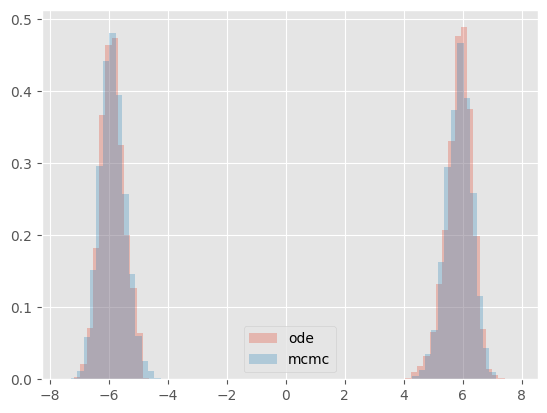

In [96]:
plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.legend()

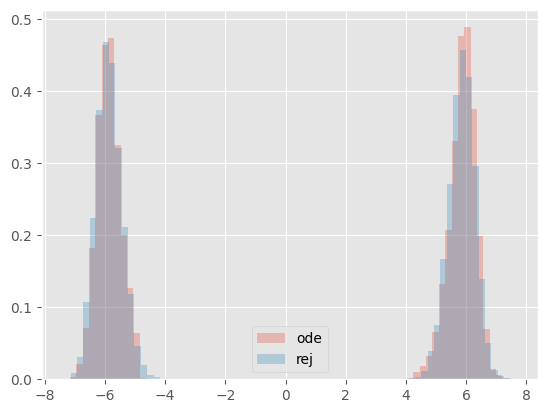

In [97]:
plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
# plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.hist(rej_samps, label="rej", alpha=0.3, density=True, bins=70);
plt.legend()

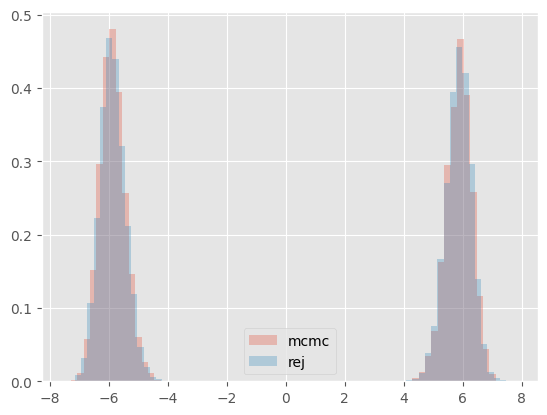

In [98]:
# plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.hist(rej_samps, label="rej", alpha=0.3, density=True, bins=70);
plt.legend()

In [170]:
wd(np.array(ode_samps4), rej_samps.squeeze(), p=2) / wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(0.06263820317115393)

In [159]:
wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(25.669467910531367)

In [167]:
wd(np.array(ode_samps4), rej_samps.squeeze(), p=2)

np.float64(1.6050963590470415)

In [168]:
wd(np.hstack(mcmc_samps4), rej_samps.squeeze(), p=2)

np.float64(1.0793946007654058)

In [169]:
wd(np.hstack(mcmc_samps4), rej_samps.squeeze(), p=2) / wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(0.04212291550192754)

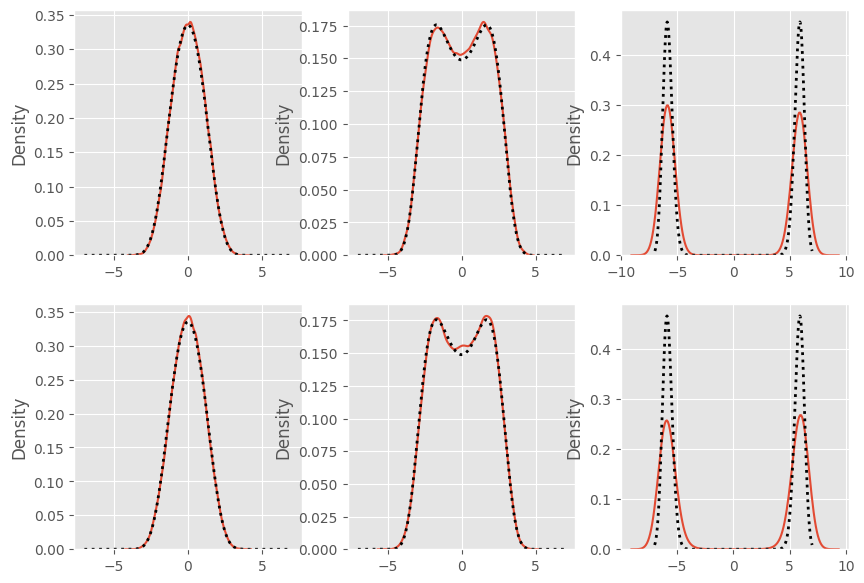

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(10, 7))

kdeplot(mcmc_samps0, label="MCMC", ax=axs[0][0], bw_adjust=0.9)
axs[0][0].plot(grids[0], density_values[0], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(ode_samps0, label="SI", ax=axs[1][0], bw_adjust=0.9)
axs[1][0].plot(grids[0], density_values[0], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(mcmc_samps1, ax=axs[0][1], bw_adjust=0.9)
axs[0][1].plot(grids[1], density_values[1], linestyle="dotted", linewidth=2, c="black")

kdeplot(ode_samps1, ax=axs[1][1], bw_adjust=1.0)
axs[1][1].plot(grids[1], density_values[1], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(np.hstack(mcmc_samps4), ax=axs[0][2], bw_adjust=0.9)
axs[0][2].plot(grids[2], density_values[2], linestyle="dotted", linewidth=2, c="black")

kdeplot(ode_samps4, ax=axs[1][2], bw_adjust=1.0)
axs[1][2].plot(grids[2], density_values[2], linestyle="dotted", linewidth=2, label="True", c="black")

<Axes: ylabel='Density'>

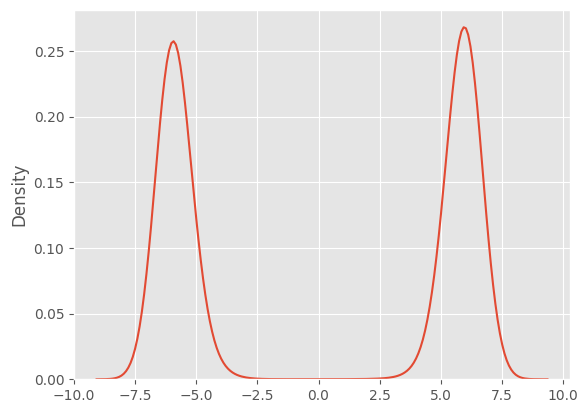

In [45]:
kdeplot(ode_samps4)

<Axes: ylabel='Density'>

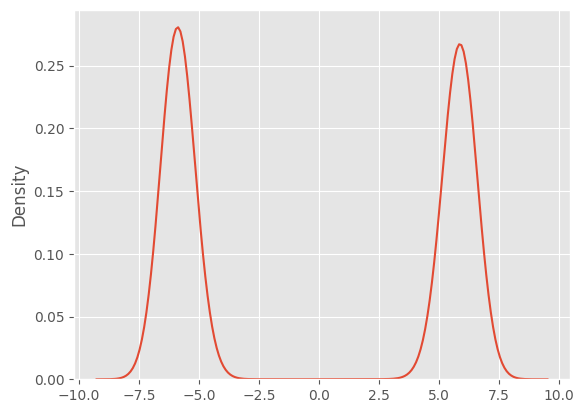

In [53]:
kdeplot(np.hstack(mcmc_samps4))